# Introduction to Dual Numbers with 'dual_autodiff'

## What are Dual Numbers
**Dual numbers** are those expressed in the form: 

$$
x + \epsilon y
$$

Where:
- $x$: the **real part**.
- $y$: the **dual part** (can represent the derivative).
- $\epsilon$ is a quantity with the defining property: $\epsilon^2 = 0$

## Why Are Dual Numbers Useful?

### Automatic Differentiation
Dual numbers are used within  **forward-mode automatic differentiation**, a method for computing **exact derivatives of** functions. 
This method has has low computational overhead and can simulteously compute a functions value $f(x)$ and its derivative $f'(x)$.

For a function $f(x)$, using dual numbers, we can compute both the value of the function and its derivative simultaneously.
Consider $f(x) = x^2$:
- Input: Dual number - $x + \epsilon$
- Output: 

$$
f(x) = (x + \epsilon)^2 = x^2 + 2x\epsilon
$$

- $x^2$: Outputs real value - the functions value
- $2x$: Outputs dual value - the functions derivative

### Applications:
- **Optimization**: In algorithms like gradient descent.
- **Machine Learning**: Enabling backpropagation and training of neural networks.
- **Physics and Engineering**: For solving differential equations.


## Using dual_autodiff
### 1: Installing dual_autodiff

1. Clone the repository:
    ```bash
    git clone https://github.com/JacobTutt/dual_autodiff_package.git
    cd dual_autodiff_package
    ```

2. Install the package in editable mode:
    ```bash
    pip install .
    ```


**Note**: To be able to run this Tutorial Notbook - install required dependencies using:

1. **From cloned Repository**
    ```bash
    pip install '.[tutorial]'
    ```

In [131]:
pip show dual_autodiff

Name: dual_autodiff
Version: 1.1.0.post13
Summary: A Python package for forward-mode automatic differentiation using dual numbers.
Home-page: https://github.com/JacobTutt/dual_autodiff
Author: Jacob Tutt
Author-email: Jacob Tutt <jacobtutt@icloud.com>
License: MIT
Location: /Users/jacobtutt/Desktop/MPhil_DIS/C1/Coursework_C1/finaltest/lib/python3.10/site-packages
Requires: numpy
Required-by: 
Note: you may need to restart the kernel to use updated packages.


### Importing the 'Dual' class

In [2]:
from dual_autodiff import Dual

### Initialising dual numbers
Example: $1 + 2\epsilon$

In [4]:
dual_number = Dual(1,2)
print(dual_number)

Dual(real=1.0, dual=2.0)


Note: Only accepts scalar inputs (int/float)

In [5]:
try:
    x = Dual(1, "two") 
except TypeError as e:
    print(e) 

'Dual part' must be a number (int or float), got str.


### Basic arithmetic operations

In [6]:
x = Dual(5,3)
y = Dual(2,1)

#### Addition: 
$(a + b\epsilon) + (c + d\epsilon) = (a + c) + (b + d)\epsilon$

Example: $(5 + 3\epsilon) + (2 + 1\epsilon) = 7 + 4\epsilon$


In [7]:
print(x+y)

Dual(real=7.0, dual=4.0)


#### Subtraction: 
$(a + b\epsilon) - (c + d\epsilon) = (a - c) + (b - d)\epsilon$

Example: $(5 + 3\epsilon) - (2 + 1\epsilon) = 3 + 2\epsilon$

In [8]:
print(x-y)

Dual(real=3.0, dual=2.0)


#### Multiplication: 
$(a + b\epsilon) \cdot (c + d\epsilon) = (a \cdot c) + (a \cdot d + b \cdot c)\epsilon$

Example: $ (5 + 3\epsilon) \cdot (2 + 1\epsilon) = (5 \cdot 2) + (5 \cdot 1 + 3 \cdot 2)\epsilon = 10 + 11\epsilon$

In [9]:
print(x*y)

Dual(real=10.0, dual=11.0)


In [12]:
import numpy as np
from dual_autodiff import *
x = np.array([Dual(2, 1), Dual(3, 2), Dual (4, 3)])
print(sin(x))
print(log(x))
print(tan(x) + cos(x) * np.pow(x, 2))

[Dual(real=0.9092974268256817, dual=-0.4161468365471424)
 Dual(real=0.1411200080598672, dual=-1.9799849932008908)
 Dual(real=-0.7568024953079283, dual=-1.960930862590836)]
[Dual(real=0.6931471805599453, dual=0.5)
 Dual(real=1.0986122886681098, dual=0.6666666666666666)
 Dual(real=1.3862943611198906, dual=0.75)]
[Dual(real=-3.8496272094500883, dual=0.4726221505506212)
 Dual(real=-9.052479012478287, dual=-12.379431070398102)
 Dual(real=-9.300476651468214, dual=27.660723239638727)]


#### Scalar Multiplication (by $k$):
$
k \cdot (a + b\epsilon) = (k \cdot a) + (k \cdot b)\epsilon $

Example:$ 2 \cdot (5 + 3\epsilon) = (2 \cdot 5) + (2 \cdot 3)\epsilon = 10 + 6\epsilon $

In [10]:
print(2*x)

Dual(real=10.0, dual=6.0)


#### Division:
$\frac{(a + b\epsilon)}{(c + d\epsilon)} = \frac{a}{c} + \frac{b \cdot c - a \cdot d}{c^2}\epsilon$

Example: $\frac{(5 + 3\epsilon)}{(2 + 1\epsilon)} = \frac{5}{2} + \frac{3 \cdot 2 - 5 \cdot 1}{2^2}\epsilon= 2.5 + 0.25\epsilon$


In [11]:
print(x/y)

Dual(real=2.5, dual=0.25)


#### Error Warning: 
- Note result of division is **undefined when real part of denominator is 0**
- Will throw ZeroDivisionError: Cannot divide by a Dual number with no real part.



In [12]:
y_error = Dual(0,1)
try:
    x/y_error
except ZeroDivisionError as e:
    print(e) 

Cannot divide by a Dual number with no real part.


#### Scalar Division (by $k$):
$\frac{(a + b\epsilon)}{k} = \frac{a}{k} + \frac{b}{k}\epsilon$

Example:
$\frac{(5 + 3\epsilon)}{2} = \frac{5}{2} + \frac{3}{2}\epsilon = 2.5 + 1.5\epsilon$

In [13]:
print(x/2)

Dual(real=2.5, dual=1.5)


#### Scalar Division (of $k$):
$\frac{k}{(a + b\epsilon)} = \frac{k}{a} - \frac{k \cdot b}{a^2}\epsilon$

Example:
$\frac{10}{(5 + 3\epsilon)} = \frac{10}{5} - \frac{10 \cdot 3}{5^2}\epsilon = 2 - 1.2\epsilon$

In [14]:
print(10/x)

Dual(real=2.0, dual=-1.2)


### More complex functions

**'dual_autodiff'** makes use of the property: 

$f(x + b\epsilon) = f(x) + f'(x) \cdot b\epsilon$

#### And currently supports the following types of functions: 
- Trigonometric (and Inverse)
- Hyperbolic
- Powers and Square Root
- Exponential and Natural Logarithms

#### Integration with pythons `math` library
- The package has been design in a way to incorporate integration with the built in python math library
- Functions can either be evaluated on Dual numbers using:
1. Using **class function**
- these can be used by default with Dual Class


    ```python
    x = Dual(2,1)
    x.sin()
    ```
2. Using **math operator**
- import maths functions created within dual_autodiff


    ```python
    from dual_autodiff import sin, cos, tan,....
    x = Dual(2,1)
    sin(x)
    ```


#### Trigonometric Functions

In [15]:
from dual_autodiff import sin, cos, tan
z = Dual(0.5,0.5)
print(f'z: {z}')
print(f'Sin(z): {sin(z)}')
print(f'Cos(z): {cos(z)}')
print(f'Tan(z): {tan(z)}')

z: Dual(real=0.5, dual=0.5)
Sin(z): Dual(real=0.479425538604203, dual=0.4387912809451864)
Cos(z): Dual(real=0.8775825618903728, dual=-0.2397127693021015)
Tan(z): Dual(real=0.5463024898437905, dual=0.6492232052047624)


#### Error Warning: 
- Note Tan is **undefined in where Cos(x) = 0**
- Will throw ValueError: The tangent function is undefined as cosine of real part equals 0

In [16]:
import math
z_error = Dual(math.pi/2,1)
try:
    tan(z_error)
except ValueError as e:
    print(e) 

Tangent undefined when cosine of real part equals 0.


#### Inverse Trignometric Functions

In [17]:
from dual_autodiff import arcsin, arccos, arctan
z = Dual(0.5,0.5)
print(f'z: {z}')
print(f'Asin(z): {arcsin(z)}')
print(f'Acos(z): {arccos(z)}')
print(f'Atan(z): {arctan(z)}')

z: Dual(real=0.5, dual=0.5)
Asin(z): Dual(real=0.5235987755982988, dual=0.5773502691896258)
Acos(z): Dual(real=1.0471975511965976, dual=-0.5773502691896258)
Atan(z): Dual(real=0.46364760900080615, dual=0.4)


#### Error Warning: 
- Note Arcsin and Arccos are **undefined ouside of domain [1,-1]**
- Will throw ValueError: Arc... are only defined for real parts in the range [-1, 1].

In [18]:
z_error = Dual(4, 0.5) 
try:
    arcsin(z_error)
except ValueError as e:
    print(e) 

Arcsine is only defined for real parts in the range [-1, 1].


#### Hyperbolic Functions

In [19]:
from dual_autodiff import sinh, cosh, tanh
z = Dual(0.5,0.5)
print(f'z: {z}')
print(f'sinh(z): {(sinh(z))}')
print(f'cosh(z): {cosh(z)}')
print(f'tanh(z): {tanh(z)}')

z: Dual(real=0.5, dual=0.5)
sinh(z): Dual(real=0.5210953054937474, dual=0.5638129826031903)
cosh(z): Dual(real=1.1276259652063807, dual=0.2605476527468737)
tanh(z): Dual(real=0.46211715726000974, dual=0.3932238664829637)


#### Exponential and Logarithim

In [20]:
from dual_autodiff import exp, log
z = Dual(0.5,0.5)
print(f'z: {z}')
print(f'exp(z): {exp(z)}')
print(f'log(z): {log(z)}')

z: Dual(real=0.5, dual=0.5)
exp(z): Dual(real=1.6487212707001282, dual=0.8243606353500641)
log(z): Dual(real=-0.6931471805599453, dual=1.0)


#### Error Warning: 
- Note logarithms are  **undefined for negetive inputs**
- Will throw ValueError: Logarithm is undefined for dual numbers with non-positive real parts.

In [21]:
z_error = Dual(-1,0.5)
try:
    log(z_error)
except ValueError as e:
    print(e) 

Logarithm is undefined for dual numbers with non-positive real parts.


#### Powers and Squareroot

In [22]:
from dual_autodiff import pow, sqrt
z = Dual(2,5)
print(f'z: {z}')
print(f'z^4: {pow(z,4)}')
print(f'z^(1/2): {sqrt(z)}')

z: Dual(real=2.0, dual=5.0)
z^4: Dual(real=16.0, dual=160.0)
z^(1/2): Dual(real=1.4142135623730951, dual=1.7677669529663687)


#### Error Warning: 
- Squareroot of 'Dual class' does not support imaginary numbers
- **Undefined for negetive inputs**
- Will throw ValueError: Square root is undefined when real parts of dual number are negetive.

In [23]:
z_error = Dual(-1,0.5)
try:
    sqrt(z_error)
except ValueError as e:
    print(e) 

Square root is undefined when real parts of dual number are negetive.


### Automatic Differentiation

**`dual_autodiff`** offers an **automatic differentiation** feature: `auto_diff`

#### About `auto_diff`

- **Takes**:
  - A **real function** $f(x)$
  - A **value** $x_0$ at which the derivative is evaluated.
  
- **Returns**:
  - Tuple containing
    - The value of $f'(x_0)$ at the specified point.
    - The derivative $f'(x_0)$ at the specified point.
  
- **Note**:
  - `auto_diff` has been designed to incorporate a wide range of mathemematical features as function inputs but some may not be currently supported and additional verification may be required.


### Example 1 (Simple)

**Function:**

$f(x) = x^3 + 3x^2 - 4$

**Derivative (Analytical):**

$f'(x) = 3x^2 + 6x$

**Evaluate at $ x = 2 $:**

$f'(2) = 3(2)^2 + 6(2) = 12 + 12 = 24$

**Derivative (auto_diff):**

In [24]:
from dual_autodiff import auto_diff

# Define the real function that can passed to auto_diff
def f_simple(x):
    return x**3 + 3 * x**2 - 4

# Compute the derivative at x = 2
deriv_x_simple = auto_diff(f_simple, 2)

print(f"The value of the function: {deriv_x_simple[0]:.1f}")
print(f"The value of the derivative: {deriv_x_simple[1]:.1f}")

The value of the function: 16.0
The value of the derivative: 24.0


### Example 2 (More Complex)

**Function:**
$f(x) = \log(\sin(x)) + x^2 \cos(x)$

**Derivative (Analytical):**

$f'(x) = \frac{\cos(x)}{\sin(x)} + 2x \cos(x) - x^2 \sin(x)$

**Evaluate at $x = 1.5$:**

Substitute \( x = 1.5 \) into \( f'(x) \):

$f'(1.5) = \frac{\cos(1.5)}{\sin(1.5)} + 2(1.5)\cos(1.5) - (1.5)^2 \sin(1.5)$
$f'(1.5) \approx -1.9612$

**Derivative (auto_diff):**

In [25]:
# Define the real function that can passed to auto_diff
def f_complex(x):
    return log(sin(x)) + x**2 * cos(x)

# Compute the derivative at x = 1.5
deriv_x_complex = auto_diff(f_complex, 1.5)
print(f"The value of the function: {deriv_x_complex[0]:.4f}")
print(f"The value of the derivative: {deriv_x_complex[1]:.4f}")

The value of the function: 0.1567
The value of the derivative: -1.9612


## Numpy Integration in V 1.1.0

The recent release of `dual_autodiff` provides extensive integration with `numpy` arrays

Below are examples of how the user can seamlessly work with arrays of dual numbers.

#### 1. **Enhanced Mathematical Functions**: 
- All mathematical functions such as `sin`, `cos`, `tan`, `exp`, `log`, `sqrt`, and more are now fully compatible with `numpy` arrays of dual numbers .

In [26]:
import numpy as np
x = np.array([Dual(1,2), Dual(0.1,0.4), Dual(3,4)])
y = np.array([Dual(3, 4), Dual(0.5, 0.2), Dual(0.6, 0.3)])

In [27]:
sin(x)
# Ie [sin(Dual(1,2)), sin(Dual(0.1,0.4)), sin(Dual(3,4))]

array([Dual(real=0.8414709848078965, dual=1.0806046117362795),
       Dual(real=0.09983341664682815, dual=0.39800166611121035),
       Dual(real=0.1411200080598672, dual=-3.9599699864017817)],
      dtype=object)

In [28]:
tanh(y)
# [tanh(Dual(3,4)), tanh(Dual(0.5,0.2)), tanh(Dual(0.6,0.3))]

array([Dual(real=0.9950547536867305, dual=0.039464148661760845),
       Dual(real=0.46211715726000974, dual=0.1572895465931855),
       Dual(real=0.5370495669980353, dual=0.21347332877616684)],
      dtype=object)

In [29]:
pow(x, 2)
# [pow(Dual(1,2), 2), pow(Dual(0.1,0.4), 2), pow(Dual(3,4), 2)]

array([Dual(real=1.0, dual=4.0),
       Dual(real=0.010000000000000002, dual=0.08000000000000002),
       Dual(real=9.0, dual=24.0)], dtype=object)

#### This includes `comparsion operators`
- Comparisions are made element wise

In [30]:
x == x
# [True, True, True]

array([ True,  True,  True])

In [31]:
x <= y
# [True, True, False]

array([ True,  True, False])

#### 2. **Advanced Auto-differentiation Functions**: 
- Extended `auto_diff` to be fully compatible with `numpy` arrays, enabling automatic differentiation over arrays of dual numbers.

In [13]:
# Define the real function that can passed to auto_diff
def f_complex(x):
    return log(sin(x)) + x**2 * cos(x)

# Numpy array of values that you wish to evaulate the function at
x = np.array([0.5, 1, 1.5])

# Compute the value and derivative at x = 0.5, 1, 1.5
deriv_x_complex = auto_diff(f_complex, x)

print(f"The values of the function: {deriv_x_complex[0]}")
print(f"The values of the derivative: {deriv_x_complex[1]}")

The values of the function: [-0.51577105  0.36769856  0.15665055]
The values of the derivative: [ 2.5882139   0.88122624 -1.96123727]


#### 3. **Multi-Function Differentiation**: 
- Introduced the `multi_auto_diff` function, allowing users to evaluate multiple functions and their derivatives at once, and even over a range (array) of points.

In [14]:
from dual_autodiff import multi_auto_diff

# Define a list of functions that can passed to multi_audo_diff
funcs = [
    lambda x: x**2 + x,
    lambda x: sin(x),
    lambda x: log(sin(x)) + x**2 * cos(x)
]
    
# Numpy array of values that you wish to evaulate each of the functions at
x = np.array([1, 2, 3])

# Compute the value and derivative at x = 1, 2, 3
multi_func_eval = multi_auto_diff(funcs, x)


print(f"Function 1: x^2 + x")
print(f"The values of the function: {multi_func_eval[0][0]}")
print(f"The values of the derivative: {multi_func_eval[0][1]}")

print(f"\nFunction 2: sin(x)")
print(f"The values of the function: {multi_func_eval[1][0]}")
print(f"The values of the derivative: {multi_func_eval[1][1]}")

print(f"\nFunction 3: log(sin(x)) + x^2 * cos(x)")
print(f"The values of the function: {multi_func_eval[2][0]}")
print(f"The values of the derivative: {multi_func_eval[2][1]}")

Function 1: x^2 + x
The values of the function: [ 2.  6. 12.]
The values of the derivative: [3. 5. 7.]

Function 2: sin(x)
The values of the function: [0.84147098 0.90929743 0.14112001]
The values of the derivative: [ 0.54030231 -0.41614684 -0.9899925 ]

Function 3: log(sin(x)) + x^2 * cos(x)
The values of the function: [  0.36769856  -1.75967038 -10.8680771 ]
The values of the derivative: [  0.88122624  -5.75943461 -14.2252876 ]


#### **Visulisation of Results**: 
- In the visulisation of the results the previous examples is used with the `multi_auto_diff` however the same results can be produced one function at a time using `auto_diff`

In [15]:
# The values we will evaluate the functions over
x_vals = np.linspace(0.01, np.pi, 100)

# Define the functions we will evaluate
def f1(x): 
    return x**2 + x

def f2(x):
    return sin(x)

def f3(x):
    return log(sin(x)) + x**2 * cos(x)

funcs = [f1, f2, f3]

# Use multi_auto_diff to evaluate the functions and their derivatives
multi_func_eval = multi_auto_diff(funcs, x_vals)


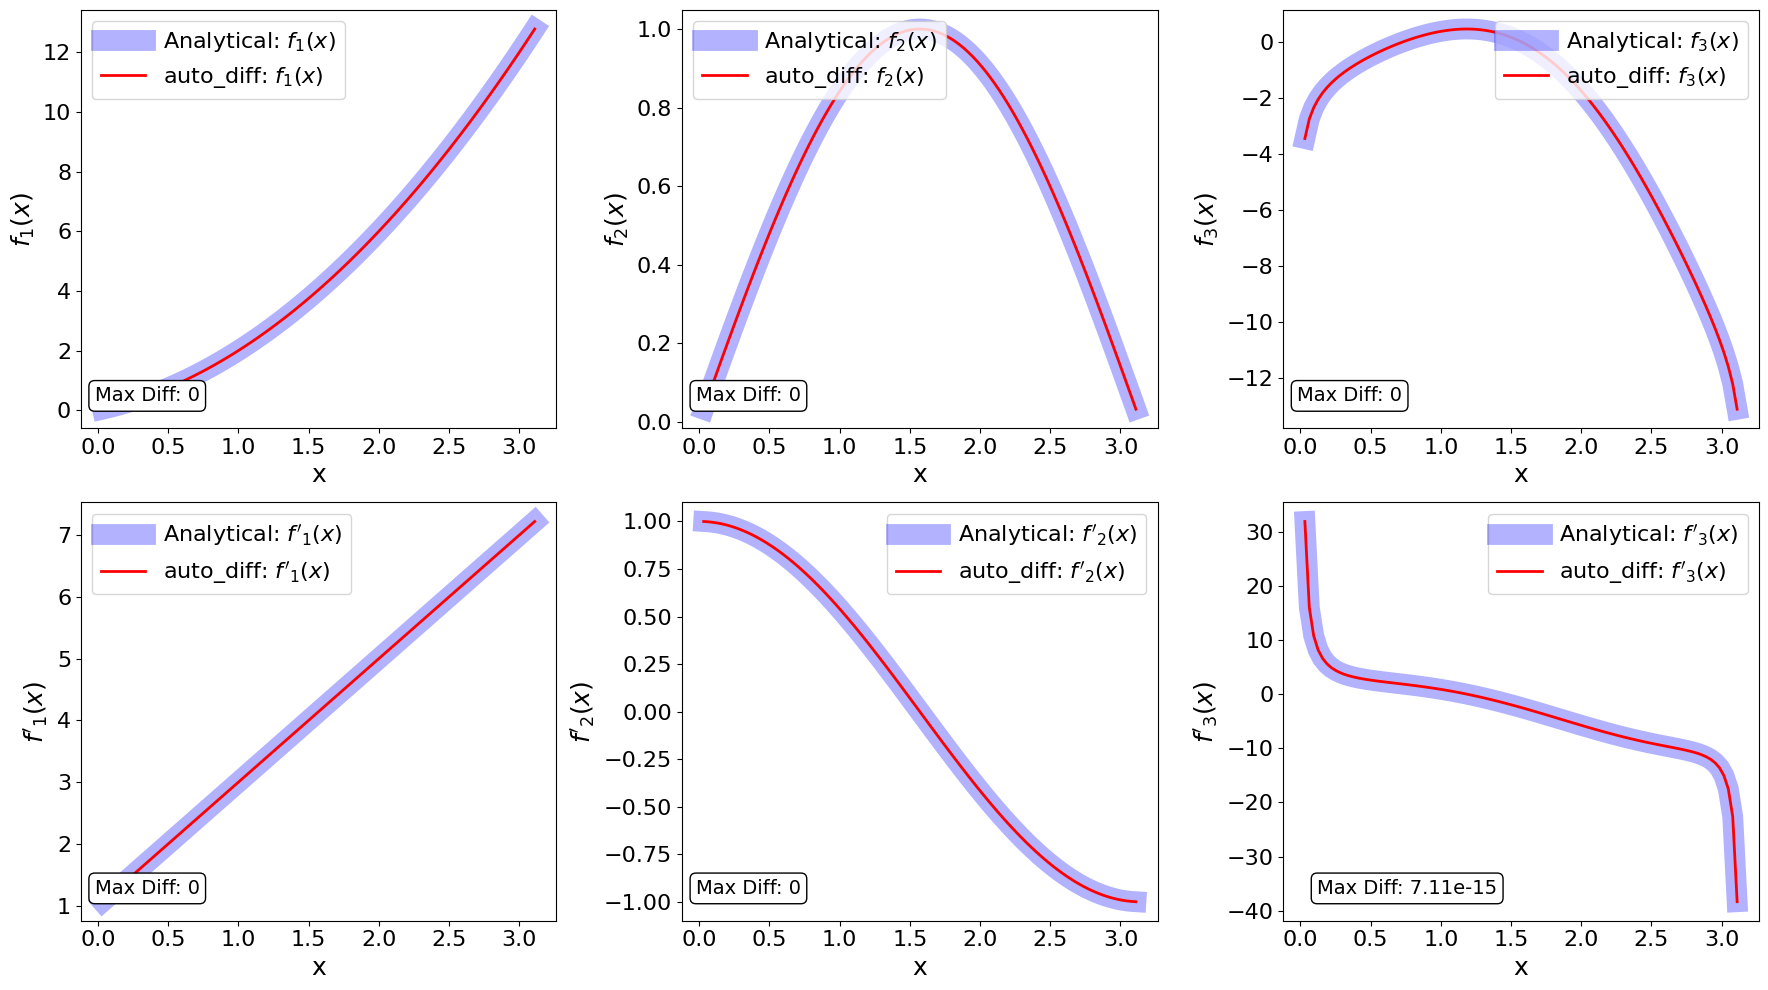

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# Define functions
def f1(x):
    return x**2 + x

def f2(x):
    return sin(x)

def f3(x):
    return log(sin(x)) + x**2 * cos(x)

# Define derivatives for the functions for verification for the plot
def f1_dev(x):
    return 2*x + 1

def f2_dev(x):
    return cos(x)

def f3_dev(x):
    return cos(x)/sin(x) + 2*x*cos(x) - x**2*sin(x)

# Function to calculate the maximum difference and display it in a box
def add_max_diff_text(ax, analytical, autodiff, xpos=0.25, ypos=0.10):
    max_diff = np.max(np.abs(analytical - autodiff))
    if max_diff == 0:
        display_text = "Max Diff: 0"
    else:
        display_text = f"Max Diff: {max_diff:.3g}"
    ax.text(
        xpos, ypos, display_text,
        transform=ax.transAxes, ha="right", va="top", fontsize=14,
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3')
    )
# Create numpy array
# Generate values between 0 and pi (not inclusive)
x_vals = np.linspace(0, np.pi, 100, endpoint=False)[1:]  # Avoid zero and pi to prevent log(sin(x)) from being undefined
funcs = [f1, f2, f3]
multi_func_eval = multi_auto_diff(funcs, x_vals)

# Verify the results in a plot
fig, axs = plt.subplots(2, 3, figsize=(18, 10))

# Plot analytical value and auto_diff value for f1
axs[0,0].plot(x_vals, f1(x_vals), color='blue', alpha=0.3, lw=15, label=r"Analytical: $f_1(x)$")
axs[0,0].plot(x_vals, multi_func_eval[0][0], color='red', lw=2, label=r"auto_diff: $f_1(x)$")
add_max_diff_text(axs[0,0], f1(x_vals), multi_func_eval[0][0])
axs[0,0].set_xlabel("x", fontsize=18)
axs[0,0].set_ylabel(r"$f_1(x)$", fontsize=18)
axs[0,0].tick_params(axis='both', which='major', labelsize=16)
axs[0,0].legend(fontsize=16, loc = 'upper left')

# Plot analytical derivative and auto_diff derivative for f1
axs[1,0].plot(x_vals, f1_dev(x_vals), color='blue', alpha=0.3, lw=15, label=r"Analytical: $f'_1(x)$")
axs[1,0].plot(x_vals, multi_func_eval[0][1], color='red', lw=2, label=r"auto_diff: $f'_1(x)$")
add_max_diff_text(axs[1,0], f1_dev(x_vals), multi_func_eval[0][1])
axs[1,0].set_xlabel("x", fontsize=18)
axs[1,0].set_ylabel(r"$f'_1(x)$", fontsize=18)
axs[1,0].tick_params(axis='both', which='major', labelsize=16)
axs[1,0].legend(fontsize=16, loc = 'upper left')

# Plot analytical value and auto_diff value for f2
axs[0,1].plot(x_vals, f2(x_vals), color='blue', alpha=0.3, lw=15, label=r"Analytical: $f_2(x)$")
axs[0,1].plot(x_vals, multi_func_eval[1][0], color='red', lw=2, label=r"auto_diff: $f_2(x)$")
add_max_diff_text(axs[0,1], f2(x_vals), multi_func_eval[1][0])
axs[0,1].set_xlabel("x", fontsize=18)
axs[0,1].set_ylabel(r"$f_2(x)$", fontsize=18)
axs[0,1].tick_params(axis='both', which='major', labelsize=16)
axs[0,1].legend(fontsize=16, loc = 'upper left')

# Plot analytical derivative and auto_diff derivative for f2
axs[1,1].plot(x_vals, f2_dev(x_vals), color='blue', alpha=0.3, lw=15, label=r"Analytical: $f'_2(x)$")
axs[1,1].plot(x_vals, multi_func_eval[1][1], color='red', lw=2, label=r"auto_diff: $f'_2(x)$")
add_max_diff_text(axs[1,1], f2_dev(x_vals), multi_func_eval[1][1])
axs[1,1].set_xlabel("x", fontsize=18)
axs[1,1].set_ylabel(r"$f'_2(x)$", fontsize=18)
axs[1,1].tick_params(axis='both', which='major', labelsize=16)
axs[1,1].legend(fontsize=16)

# Plot analytical value and auto_diff value for f3
axs[0,2].plot(x_vals, f3(x_vals), color='blue', alpha=0.3, lw=15, label=r"Analytical: $f_3(x)$")
axs[0,2].plot(x_vals, multi_func_eval[2][0], color='red', lw=2, label=r"auto_diff: $f_3(x)$")
add_max_diff_text(axs[0,2], f3(x_vals), multi_func_eval[2][0])
axs[0,2].set_xlabel("x", fontsize=18)
axs[0,2].set_ylabel(r"$f_3(x)$", fontsize=18)
axs[0,2].tick_params(axis='both', which='major', labelsize=16)
axs[0,2].legend(fontsize=16, loc = 'upper right')

# Plot analytical derivative and auto_diff derivative for f3
axs[1,2].plot(x_vals, f3_dev(x_vals), color='blue', alpha=0.3, lw=15, label=r"Analytical: $f'_3(x)$")
axs[1,2].plot(x_vals, multi_func_eval[2][1], color='red', lw=2, label=r"auto_diff: $f'_3(x)$")
add_max_diff_text(axs[1,2], f3_dev(x_vals), multi_func_eval[2][1], xpos=0.45, ypos=0.10)
axs[1,2].set_xlabel("x", fontsize=18)
axs[1,2].set_ylabel(r"$f'_3(x)$", fontsize=18)
axs[1,2].tick_params(axis='both', which='major', labelsize=16)
axs[1,2].legend(fontsize=16)

plt.tight_layout()
plt.show()

## Note the remaining sections of this Notebook would not typically be included in a packages tutorial but has been for assesment purposes
### Comparison with numerical methdos
- To jusify the use of the package the packages accuracy


In [62]:
import numpy as np
import time
import tracemalloc

# Define the benchmark function f3(x) to be evaluated
def f3(x):
    return log(sin(x)) + x**2 * cos(x)

# Define the analytical derivative of f3(x) for comparison
def f3_derivative(x):
    return (cos(x) / sin(x)) + 2 * x * cos(x) - x**2 * sin(x)

# Define the values of x to evaluate the function at:
x_vals = np.linspace(0, np.pi, 100, endpoint=False)[1:]  # Avoid zero and pi to prevent log(sin(x)) from being undefined

# Determine true derivative values
true_derivatives = f3_derivative(x_vals)


# Forward difference method
def forward_difference(f, x, h):
    """
    Approximate the derivative of f at x using the forward difference method.
    """
    return (f(x + h) - f(x)) / h

# Central difference method
def central_difference(f, x, h):
    """
    Approximate the derivative of f at x using the central difference method.
    """
    return (f(x + h) - f(x - h)) / (2 * h)


def time_memory_check(method, f, x_vals, h=None):
    """
    Benchmarks the time and memory usage of a differentiation method.

    Parameters:
        method (callable): Differentiation method (e.g., forward_difference, central_difference, or auto_diff).
        f (callable): The function to differentiate.
        x_vals (numpy.ndarray): Input values for evaluating the derivative.
        h (float, optional): Step size for numerical differentiation. Not needed for auto_diff.

    Returns:
        tuple: Average time (seconds) and memory usage (kilobytes) for the differentiation method.
    """
    # Initialize variables to store total time and memory
    total_duration = 0
    total_memory = 0

    # Number of iterations for benchmarking
    iterations = 100

    for _ in range(iterations):
        # Start tracking memory usage
        tracemalloc.start()

        # Measure time taken for differentiation
        start_time = time.time()
        if h is not None:  # If `h` is provided (e.g., forward/central difference)
            _ = method(f, x_vals, h)
        else:  # For auto_diff or other methods without step size
            _ = method(f, x_vals)
        duration = time.time() - start_time
        # Capture memory usage
        memory = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        # Accumulate the results
        total_duration += duration
        total_memory += memory[1]  # Peak memory usage

    # Compute averages
    avg_duration = total_duration / iterations
    avg_memory = total_memory / iterations / 1024  # Convert to kilobytes

    return avg_duration, avg_memory


In [98]:
# Calculate the average time and memory for each method
# Time and memory auto_diff
avg_time_ad, avg_mem_ad = time_memory_check(auto_diff, f3, x_vals)
# Display results
print(f"AutoDiff - Avg Time: {avg_time_ad:.6f}s, Avg Memory: {avg_mem_ad:.2f}KB")

# Time and memory forward_difference h = (0.1, 0.001, 0.0001)
avg_time_fd_1, avg_mem_fd_1 = time_memory_check(forward_difference, f3, x_vals, h=0.1)
avg_time_fd_10, avg_mem_fd_10 = time_memory_check(forward_difference, f3, x_vals, h=1e-10)
# Display results
print(f"Forward Difference (h=0.1) - Avg Time: {avg_time_fd_1:.6f}s, Avg Memory: {avg_mem_fd_1:.2f}KB")
print(f"Forward Difference (h=$1 \\times 10^{{-10}} $) - Avg Time: {avg_time_fd_10:.6f}s, Avg Memory: {avg_mem_fd_10:.2f}KB")


# Time and memory central_difference h = (0.1, 0.001, 0.0001)
avg_time_cd_01, avg_mem_cd_01 = time_memory_check(central_difference, f3, x_vals, h=0.1)
avg_time_cd_001, avg_mem_cd_001 = time_memory_check(central_difference, f3, x_vals, h=1e-10)
# Display results
print(f"Central Difference (h=0.1) - Avg Time: {avg_time_cd_01:.6f}s, Avg Memory: {avg_mem_cd_01:.2f}KB")
print(f"Central Difference (h=$1 \\times 10^{{-10}} $) - Avg Time: {avg_time_cd_001:.6f}s, Avg Memory: {avg_mem_cd_001:.2f}KB")



AutoDiff - Avg Time: 0.006733s, Avg Memory: 6.10KB
Forward Difference (h=0.1) - Avg Time: 0.000019s, Avg Memory: 4.34KB
Forward Difference (h=$1 \times 10^{-10} $) - Avg Time: 0.000017s, Avg Memory: 4.34KB
Central Difference (h=0.1) - Avg Time: 0.000023s, Avg Memory: 5.21KB
Central Difference (h=$1 \times 10^{-10} $) - Avg Time: 0.000019s, Avg Memory: 5.20KB


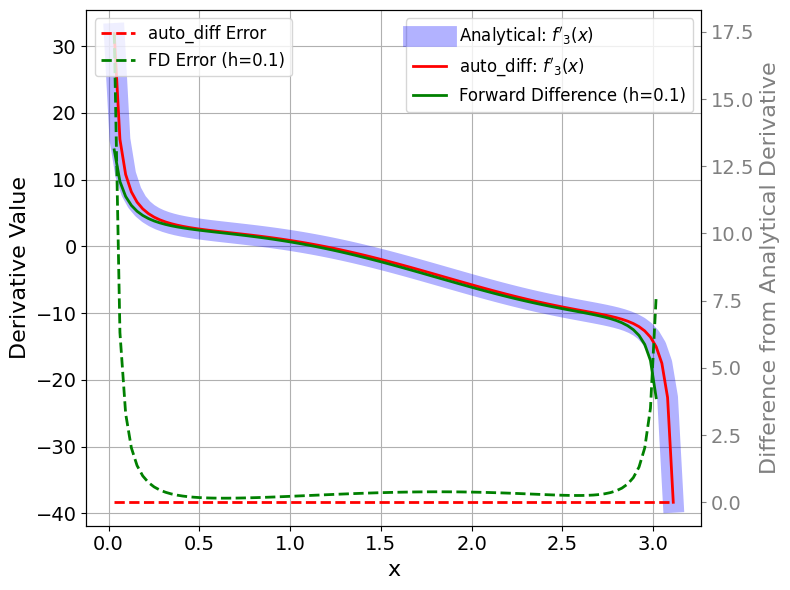

In [88]:
fd_01_results = forward_difference(f3, x_vals, h=0.1)
_, ad_results = auto_diff(f3, x_vals)

# Create the main figure and axis
fig, ax1 = plt.subplots(figsize=(8, 6))

# Plot analytical and numerical derivative results
ax1.plot(x_vals, true_derivatives, color='blue', alpha=0.3, lw=15, label=r"Analytical: $f'_3(x)$")
ax1.plot(x_vals, ad_results, color='red', lw=2, label=r"auto_diff: $f'_3(x)$")
ax1.plot(x_vals, fd_01_results, color='green', lw=2, label=r"Forward Difference (h=0.1)")


# Formatting for primary axis
ax1.set_xlabel("x", fontsize=16)
ax1.set_ylabel("Derivative Value", fontsize=16)
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.legend(fontsize=12)
ax1.grid()

# Create a secondary y-axis for the differences
ax2 = ax1.twinx()

# Compute differences between numerical methods and true derivatives
ad_diff = abs(ad_results - true_derivatives)
fd_01_diff = abs(fd_01_results - true_derivatives)

# Plot the differences on the secondary axis
ax2.plot(x_vals, ad_diff, color='red', linestyle='dashed', label="auto_diff Error", lw=2)
ax2.plot(x_vals, fd_01_diff, color='green', linestyle='dashed', label="FD Error (h=0.1)", lw=2)


# Formatting for secondary axis
ax2.set_ylabel("Difference from Analytical Derivative", fontsize=16, color='gray')
ax2.tick_params(axis='y', labelsize=14, colors='gray')

# Add secondary legend
lines, labels = ax2.get_legend_handles_labels()
ax2.legend(lines, labels, fontsize=12, loc='upper left')

plt.tight_layout()
plt.show()

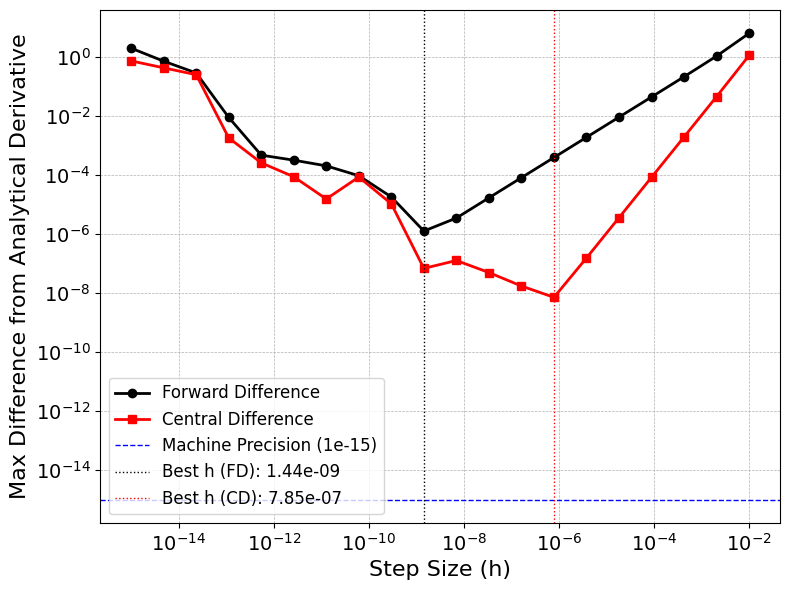

Best h for Forward Difference: 1.44e-09 with error 1.27e-06
Best h for Central Difference: 7.85e-07  with error 7.18e-09


In [99]:
true_derivatives = f3_derivative(x_vals)
log_spaced_h = np.logspace(-15, -2, 20)
fd_error = []
cd_error = []
for h in log_spaced_h:
    fd_error.append(np.abs(np.max(true_derivatives - forward_difference(f3, x_vals, h))))
    cd_error.append(np.abs(np.max(true_derivatives - central_difference(f3, x_vals, h))))


# Machine precision line
machine_precision = 1e-15

# Find the best step size (h) for Forward Difference and Central Difference
best_h_fd = log_spaced_h[np.argmin(fd_error)]
best_h_cd = log_spaced_h[np.argmin(cd_error)]

# Create the main figure and axis
fig, ax1 = plt.subplots(figsize=(8, 6))

# Plot Forward Difference and Central Difference errors
ax1.loglog(log_spaced_h, fd_error, label="Forward Difference", marker='o', color='black', lw=2)
ax1.loglog(log_spaced_h, cd_error, label="Central Difference", marker='s', color='red', lw=2)

# Add a horizontal line for machine precision
ax1.axhline(machine_precision, color='blue', linestyle='--', linewidth=1, label="Machine Precision (1e-15)")

# Add vertical lines for the best h values
ax1.axvline(best_h_fd, color='black', linestyle='dotted', linewidth=1, label=f"Best h (FD): {best_h_fd:.2e}")
ax1.axvline(best_h_cd, color='red', linestyle='dotted', linewidth=1, label=f"Best h (CD): {best_h_cd:.2e}")

# Formatting the plot
ax1.set_xlabel("Step Size (h)", fontsize=16)
ax1.set_ylabel("Max Difference from Analytical Derivative", fontsize=16)
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.legend(fontsize=12)
ax1.grid(which="both", linestyle="--", linewidth=0.5)

# Adjust layout for clarity
plt.tight_layout()

# Show the plot
plt.show()

# Print the best h values
print(f"Best h for Forward Difference: {best_h_fd:.2e} with error {np.min(fd_error):.2e}")
print(f"Best h for Central Difference: {best_h_cd:.2e}  with error {np.min(cd_error):.2e}")

### Cythonised version of package

`dual_autodiff` offers an **cythonized** version: `dual_autodiff_x`

- The **Cython** version significantly enhances computational efficiency by converting the original Python script into **C**, which is then **compiled into machine** code at build time. 

- In contrast, Python is an **interpreted language**, meaning the code is compiled during runtime, which has significantly more overhead and results in **slower run time**.

#### Using cythonised version

- The package and its wheels includes both the **python** version and **cython** version as subpackages: **dual_autodiff** and **dual_autodiff_x** respectively
- Their functionallity is exact the same as above apart from importing
- In this all cython functions are imported `as function_x` but this is just to stop clashes as both versions are used

##### Demonstration of auto_diff from dual_autodiff_x

In [51]:
from dual_autodiff_x import auto_diff as auto_diff_x

# Define the real function that can passed to auto_diff
def f_simple(x):
    return x**3 + 3 * x**2 - 4

# Compute the derivative at x = 2
deriv_x_simple = auto_diff_x(f_simple, 2)

print(f"The value of the function: {deriv_x_simple[0]:.1f}")
print(f"The value of the derivative: {deriv_x_simple[1]:.1f}")

The value of the function: 16.0
The value of the derivative: 24.0


### Demonstration of time and memory differences

In [103]:
import time
import tracemalloc
from dual_autodiff_x import auto_diff as auto_diff_x
from dual_autodiff_x import Dual as Dual_x
from dual_autodiff_x import sin as sin_x, log as log_x, tanh as tanh_x, pow as pow_x, cos as cos_x


def time_memory_check_cython (f,f_x, x_vals):
    """
    Benchmarks the time and memory usage of a differentiation method.

    Parameters:
        method (callable): Differentiation method (e.g., forward_difference, central_difference, or auto_diff).
        f (callable): The function to differentiate.
        x_vals (numpy.ndarray): Input values for evaluating the derivative.
        h (float, optional): Step size for numerical differentiation. Not needed for auto_diff.

    Returns:
        tuple: Average time (seconds) and memory usage (kilobytes) for the differentiation method.
    """
    # Initialize variables to store total time and memory
    total_python_duration = 0
    total_cython_duration = 0
    total_python_memory = 0
    total_cython_memory = 0

    # Number of iterations for benchmarking
    iterations = 100

    for _ in range(iterations):

        # Compute the function at input value using Python version
        tracemalloc.start()
        start_time = time.time()
        _ =  auto_diff(f, x_vals)
        python_duration = time.time() - start_time
        python_memory = tracemalloc.get_traced_memory()
        tracemalloc.reset_peak()

        # Compute the derivative at input value using Cython version
        start_time = time.time()
        _ =  auto_diff_x(f_x, x_vals)
        cython_duration = time.time() - start_time
        cython_memory = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        # Accumulate the results
        total_python_duration += python_duration
        total_cython_duration += cython_duration
        total_python_memory += python_memory[1]
        total_cython_memory += cython_memory[1]

    # Compute the averages
    average_python_duration = total_python_duration / iterations
    average_cython_duration = total_cython_duration / iterations
    average_python_memory = total_python_memory / iterations / 1024  # Convert to KB
    average_cython_memory = total_cython_memory / iterations / 1024  # Convert to KB

    return average_python_duration, average_cython_duration, average_python_memory, average_cython_memory

In [118]:
# Define inputs for time and memory check
single_inputs = 1
array_inputs = np.array([1,1,1,1,1,1,1,1])

# Time and memory check for sin - single input
sin_py_time, sin_cy_time, sin_py_memory, sin_cy_memory = time_memory_check_cython(lambda x: sin(x),lambda x: sin_x(x), single_inputs)
# Time and memory check for sin - array input
sin_array_py_time, sin_array_cy_time, sin_array_py_memory, sin_array_cy_memory = time_memory_check_cython(lambda x: sin(x),lambda x: sin_x(x), array_inputs)
# Determine percentages changes in time and memory
sin_time_change = (sin_py_time - sin_cy_time) / sin_py_time * 100
sin_memory_change = (sin_py_memory - sin_cy_memory) / sin_py_memory * 100
sin_array_time_change = (sin_array_py_time - sin_array_cy_time) / sin_array_py_time * 100
sin_array_memory_change = (sin_array_py_memory - sin_array_cy_memory) / sin_array_py_memory * 100


# Time and memory check for log - single input
log_py_time, log_cy_time, log_py_memory, log_cy_memory = time_memory_check_cython(lambda x: log(x),lambda x: log_x(x), single_inputs)
# Time and memory check for log - array input
log_array_py_time, log_array_cy_time, log_array_py_memory, log_array_cy_memory = time_memory_check_cython(lambda x: log(x),lambda x: log_x(x), array_inputs)
# Determine percentages changes in time and memory
log_time_change = (log_py_time - log_cy_time) / log_py_time * 100
log_memory_change = (log_py_memory - log_cy_memory) / log_py_memory * 100
log_array_time_change = (log_array_py_time - log_array_cy_time) / log_array_py_time * 100
log_array_memory_change = (log_array_py_memory - log_array_cy_memory) / log_array_py_memory * 100


# Time and memory check for tanh - single input
tanh_py_time, tanh_cy_time, tanh_py_memory, tanh_cy_memory = time_memory_check_cython(lambda x: tanh(x),lambda x: tanh_x(x), single_inputs)
# Time and memory check for tanh - array input
tanh_array_py_time, tanh_array_cy_time, tanh_array_py_memory, tanh_array_cy_memory = time_memory_check_cython(lambda x: tanh(x),lambda x: tanh_x(x), array_inputs)
# Determine percentages changes in time and memory
tanh_time_change = (tanh_py_time - tanh_cy_time) / tanh_py_time * 100
tanh_memory_change = (tanh_py_memory - tanh_cy_memory) / tanh_py_memory * 100
tanh_array_time_change = (tanh_array_py_time - tanh_array_cy_time) / tanh_array_py_time * 100
tanh_array_memory_change = (tanh_array_py_memory - tanh_array_cy_memory) / tanh_array_py_memory * 100

# Time and memory check for pow - single input
pow_py_time, pow_cy_time, pow_py_memory, pow_cy_memory = time_memory_check_cython(lambda x: pow(x, 3),lambda x: pow_x(x, 3), single_inputs)
# Time and memory check for pow - array input
pow_array_py_time, pow_array_cy_time, pow_array_py_memory, pow_array_cy_memory = time_memory_check_cython(lambda x: pow(x, 3),lambda x: pow_x(x, 3), array_inputs)
# Determine percentages changes in time and memory
pow_time_change = (pow_py_time - pow_cy_time) / pow_py_time * 100
pow_memory_change = (pow_py_memory - pow_cy_memory) / pow_py_memory * 100
pow_array_time_change = (pow_array_py_time - pow_array_cy_time) / pow_array_py_time * 100
pow_array_memory_change = (pow_array_py_memory - pow_array_cy_memory) / pow_array_py_memory * 100

# Time and memory check for log(sin(x)) + x**2 + cos(x) - single input
complex_py_time, complex_cy_time, complex_py_memory, complex_cy_memory = time_memory_check_cython(lambda x: log(sin(x)) + x**2 + cos(x),lambda x: log_x(sin_x(x)) + pow_x(x, 2) + cos_x(x), single_inputs)
# Time and memory check for log(sin(x)) + x**2 + cos(x) - array input
complex_array_py_time, complex_array_cy_time, complex_array_py_memory, complex_array_cy_memory = time_memory_check_cython(lambda x: log(sin(x)) + x**2 + cos(x),lambda x: log_x(sin_x(x)) + pow_x(x, 2) + cos_x(x), array_inputs)
# Determine percentages changes in time and memory
complex_time_change = (complex_py_time - complex_cy_time) / complex_py_time * 100
complex_memory_change = (complex_py_memory - complex_cy_memory) / complex_py_memory * 100
complex_array_time_change = (complex_array_py_time - complex_array_cy_time) / complex_array_py_time * 100
complex_array_memory_change = (complex_array_py_memory - complex_array_cy_memory) / complex_array_py_memory * 100


# Display results in a table
import pandas as pd
from tabulate import tabulate
data = {
    'Function': [r'$\sin$', r'$\log$', r'$\tanh$', r'$\mathrm{pow(2)}$', r'$\log(\sin(x)) + x^2 + \cos(x)$'],
    'Time Change Single (%)': [sin_time_change, log_time_change, tanh_time_change, pow_time_change, complex_time_change],
    'Time Change Array (%)': [sin_array_time_change, log_array_time_change, tanh_array_time_change, pow_array_time_change, complex_array_time_change],
    'Memory Change Single (%)': [sin_memory_change, log_memory_change, tanh_memory_change, pow_memory_change, complex_memory_change],
    'Memory Change Array (%)': [sin_array_memory_change, log_array_memory_change, tanh_array_memory_change, pow_array_memory_change, complex_array_memory_change]
}

df = pd.DataFrame(data)

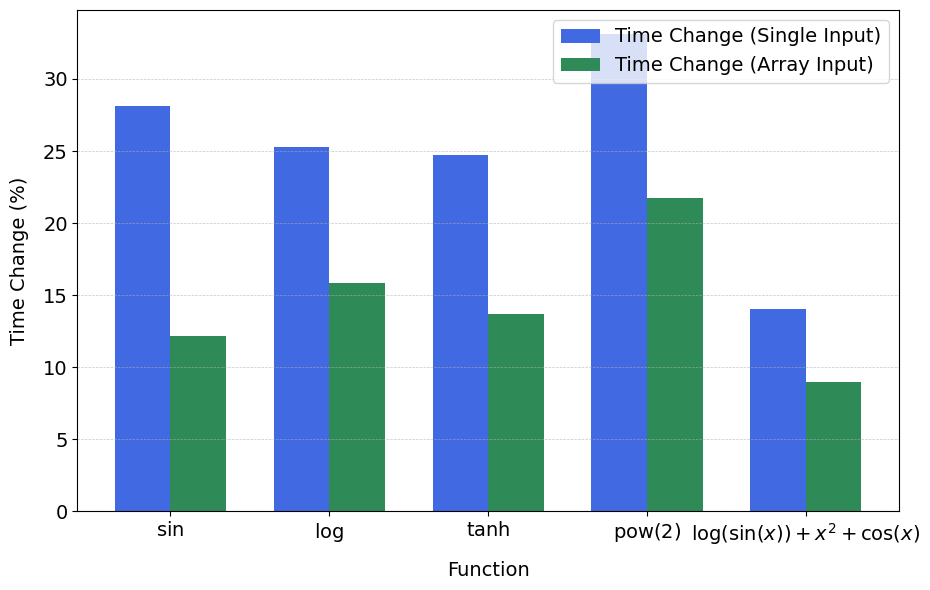

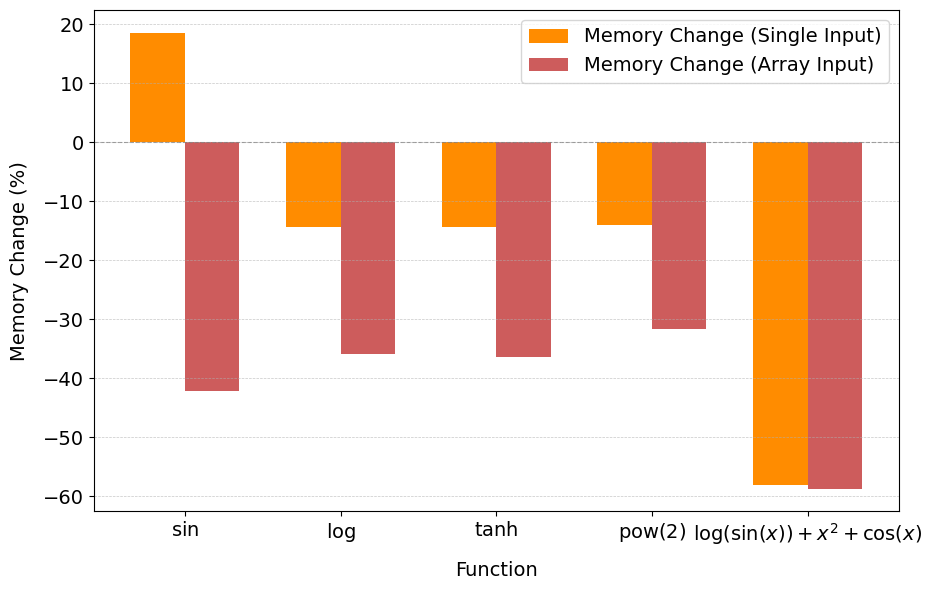

In [119]:

# Configurable plotting variables
fontsize_labels = 14
fontsize_title = 14
fontsize_ticks = 14
fontsize_legend = 14
labelpad_axis = 10
rotation_xticks = 0
bar_width = 0.35
figsize = (9.5, 6)

# Plot Time Change
fig, ax = plt.subplots(figsize=figsize)
index = np.arange(len(df['Function']))

# Time change bars
bar1 = ax.bar(index - bar_width / 2, df['Time Change Single (%)'], bar_width, label='Time Change (Single Input)', color='royalblue')
bar2 = ax.bar(index + bar_width / 2, df['Time Change Array (%)'], bar_width, label='Time Change (Array Input)', color='seagreen')

# Customizing the time change plot
ax.set_xlabel('Function', fontsize=fontsize_labels, labelpad=labelpad_axis)
ax.set_ylabel('Time Change (%)', fontsize=fontsize_labels, labelpad=labelpad_axis)
ax.set_xticks(index)
ax.tick_params(axis='y', labelsize=fontsize_ticks)
ax.set_xticklabels(df['Function'], fontsize=fontsize_ticks, rotation=rotation_xticks, ha='center')
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.7)  # Add baseline
ax.legend(fontsize=fontsize_legend, loc='upper right')
ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()

# Plot Memory Change
fig, ax = plt.subplots(figsize=figsize)

# Memory change bars
bar1 = ax.bar(index - bar_width / 2, df['Memory Change Single (%)'], bar_width, label='Memory Change (Single Input)', color='darkorange')
bar2 = ax.bar(index + bar_width / 2, df['Memory Change Array (%)'], bar_width, label='Memory Change (Array Input)', color='indianred')

# Customizing the memory change plot
ax.set_xlabel('Function', fontsize=fontsize_labels, labelpad=labelpad_axis)
ax.set_ylabel('Memory Change (%)', fontsize=fontsize_labels, labelpad=labelpad_axis)
ax.set_xticks(index)
ax.tick_params(axis='y', labelsize=fontsize_ticks)
ax.set_xticklabels(df['Function'], fontsize=fontsize_ticks, rotation=rotation_xticks, ha='center')
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.7)  # Add baseline
ax.legend(fontsize=fontsize_legend, loc='upper right')
ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()

In [129]:
# Define a range of array sizes
array_sizes = [1, 50, 100, 200, 400, 600, 800, 1000]
python_times = []
cython_times = []

for size in array_sizes:
    print(f'Analysing array size: {size}')
    # Generate inputs for both Python and Cython functions
    array_inputs = np.array([1] * size)
    
    # Time and memory check for a function (e.g., sin)
    py_time, cy_time, _, _ = time_memory_check_cython(lambda x: sin(x), lambda x: sin_x(x), array_inputs)
    
    python_times.append(py_time)
    cython_times.append(cy_time)

Analysing array size: 1
Analysing array size: 50
Analysing array size: 100
Analysing array size: 200
Analysing array size: 400
Analysing array size: 600
Analysing array size: 800
Analysing array size: 1000


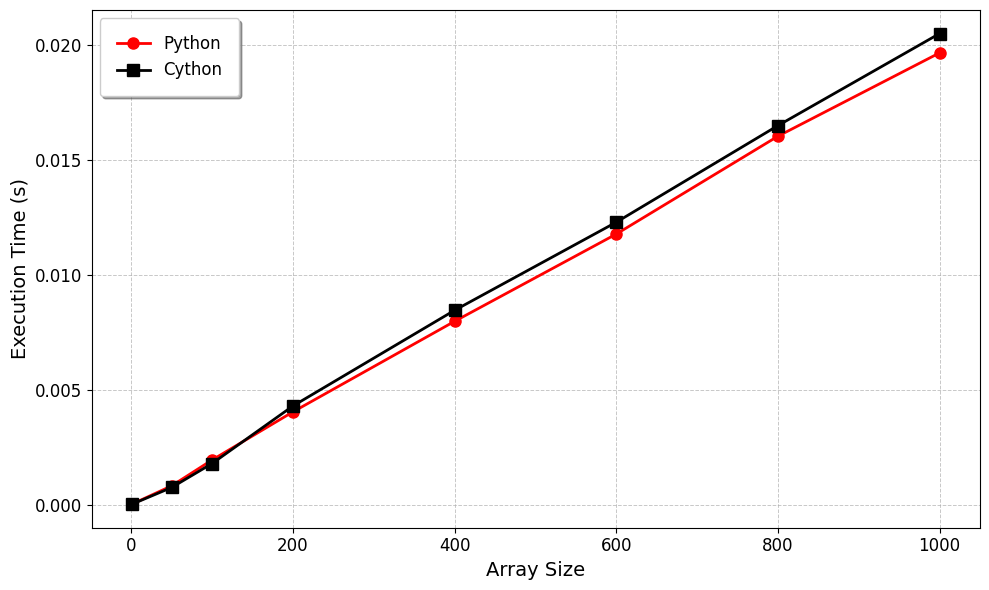

In [130]:
# Plot results
# Configurable plot parameters
fontsize_labels = 14
fontsize_title = 16
fontsize_legend = 12
linewidth = 2
markersize = 8

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(array_sizes, python_times, label='Python', marker='o', linestyle='-', linewidth=linewidth, markersize=markersize, color='red')
plt.plot(array_sizes, cython_times, label='Cython', marker='s', linestyle='-', linewidth=linewidth, markersize=markersize, color='black')
plt.xlabel('Array Size', fontsize=fontsize_labels)
plt.ylabel('Execution Time (s)', fontsize=fontsize_labels)
plt.xticks(fontsize=fontsize_labels - 2)
plt.yticks(fontsize=fontsize_labels - 2)
plt.grid(True, linestyle='--', linewidth=0.7, alpha=0.7)
plt.legend(fontsize=fontsize_legend, loc='upper left', frameon=True, shadow=True, borderpad=1)
plt.tight_layout()
plt.show()